In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-learn scipy -q

import os, gc, json, warnings
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import (f1_score, precision_score,
                              recall_score, cohen_kappa_score)
import pandas as pd
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json, pandas as pd
from scipy.stats import friedmanchisquare

RESULTS_DIR = '/content/drive/MyDrive/tesis_palta/resultados_OE1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TABLA FINAL

In [ ]:
modelos = ['MobileNetV3Small', 'MobileNetV2', 'EfficientNetB0']
todos_resultados = {}

for nombre in modelos:
    ruta = f'{RESULTS_DIR}/resultados_{nombre}.json'
    with open(ruta, 'r') as f:
        todos_resultados[nombre] = json.load(f)
    df_temp = pd.DataFrame(todos_resultados[nombre])
    print(f"✅ {nombre}: F1={df_temp['F1'].mean():.4f} Kappa={df_temp['Kappa'].mean():.4f}")

print("\n=== TABLA COMPARATIVA FINAL — OE1 ===\n")
resumen = []
for nombre, res in todos_resultados.items():
    df = pd.DataFrame(res)
    resumen.append({
        'Modelo':    nombre,
        'Precisión': f"{df['Precision'].mean():.4f} ± {df['Precision'].std():.4f}",
        'Recall':    f"{df['Recall'].mean():.4f} ± {df['Recall'].std():.4f}",
        'F1-Score':  f"{df['F1'].mean():.4f} ± {df['F1'].std():.4f}",
        'Kappa':     f"{df['Kappa'].mean():.4f} ± {df['Kappa'].std():.4f}",
    })

tabla = pd.DataFrame(resumen)
print(tabla.to_string(index=False))

# Prueba de Friedman
f1_mv3   = [r['F1'] for r in todos_resultados['MobileNetV3Small']]
f1_mv2   = [r['F1'] for r in todos_resultados['MobileNetV2']]
f1_effb0 = [r['F1'] for r in todos_resultados['EfficientNetB0']]

stat, p_val = friedmanchisquare(f1_mv3, f1_mv2, f1_effb0)
print(f"\n=== PRUEBA DE FRIEDMAN ===")
print(f"χ²: {stat:.4f}  |  p-valor: {p_val:.6f}")
print("✅ Diferencias significativas (p < 0.05)"
      if p_val < 0.05 else "⚠️ Sin diferencias significativas")

tabla.to_csv(f'{RESULTS_DIR}/tabla_OE1_final.csv', index=False)
print(f"\n✅ Tabla guardada en Drive")

✅ MobileNetV3Small: F1=0.8882 Kappa=0.8315
✅ MobileNetV2: F1=0.9104 Kappa=0.8650
✅ EfficientNetB0: F1=0.9161 Kappa=0.8735

=== TABLA COMPARATIVA FINAL — OE1 ===

          Modelo       Precisión          Recall        F1-Score           Kappa
MobileNetV3Small 0.8901 ± 0.0145 0.8877 ± 0.0154 0.8882 ± 0.0149 0.8315 ± 0.0231
     MobileNetV2 0.9133 ± 0.0253 0.9100 ± 0.0285 0.9104 ± 0.0281 0.8650 ± 0.0427
  EfficientNetB0 0.9176 ± 0.0214 0.9157 ± 0.0214 0.9161 ± 0.0213 0.8735 ± 0.0321

=== PRUEBA DE FRIEDMAN ===
χ²: 7.4000  |  p-valor: 0.024724
✅ Diferencias significativas (p < 0.05)

✅ Tabla guardada en Drive


Gráficos de comparación

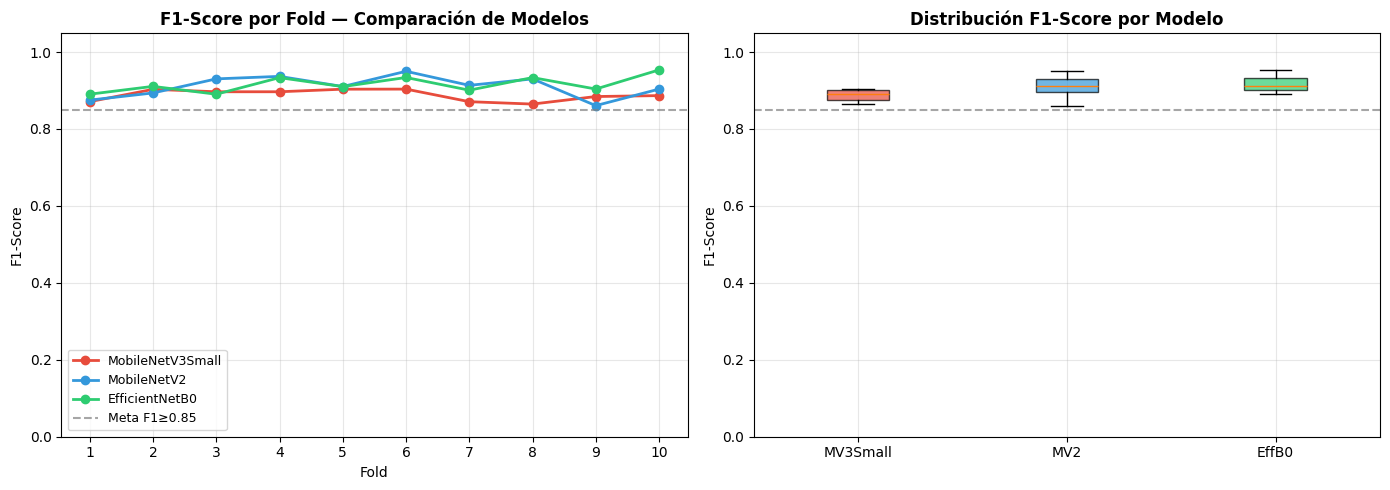

✅ Gráfico guardado en Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

modelos_nombres = ['MobileNetV3Small', 'MobileNetV2', 'EfficientNetB0']
colores = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — F1 por fold
ax1 = axes[0]
for nombre, color in zip(modelos_nombres, colores):
    folds_f1 = [r['F1'] for r in todos_resultados[nombre]]
    ax1.plot(range(1, len(folds_f1)+1), folds_f1,
             marker='o', label=nombre, color=color, linewidth=2)

ax1.axhline(y=0.85, color='gray', linestyle='--',
            alpha=0.7, label='Meta F1≥0.85')
ax1.set_title('F1-Score por Fold — Comparación de Modelos',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Fold')
ax1.set_ylabel('F1-Score')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)
ax1.set_xticks(range(1, 11))

# Gráfico 2 — Boxplot F1
ax2 = axes[1]
datos_box = [[r['F1'] for r in todos_resultados[n]]
             for n in modelos_nombres]
bp = ax2.boxplot(datos_box,
                  labels=['MV3Small', 'MV2', 'EffB0'],
                  patch_artist=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)
ax2.set_title('Distribución F1-Score por Modelo',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/grafico_comparacion_OE1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en Drive")